## ネットワーク分析（SIRモデルなど）
https://www.nii.ac.jp/userdata/shimin/documents/H19/071113_6thlec.pdf

ノード：ネットワークの点、個々の要素

エッジ：ノード間の接続、関係性

次数：1つのノードに接続されているエッジの数

L: 平均最短経路長
-  ネットワーク内の任意の2ノード間の最短経路の平均値

C: クラスタリング係数
- あるノードの隣接ノード同士がどれだけ互いに接続されているかを示す指標
- 0から1の範囲で表され、1に近いほど隣接ノード同士が接続されていることを示す

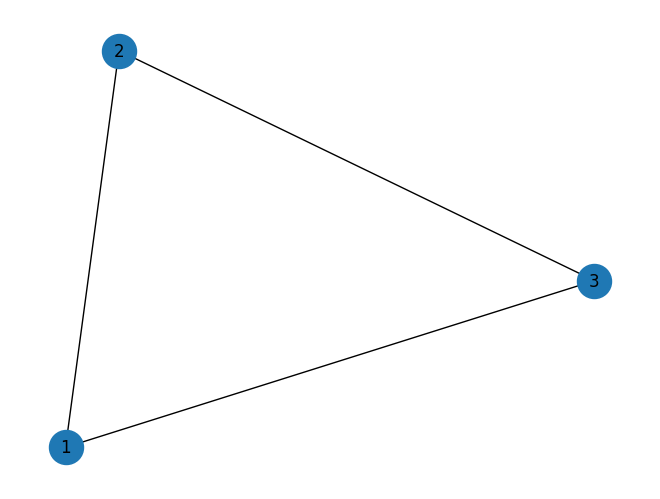

L: 1.0, C: 1.0


In [16]:
import networkx as nx
import matplotlib.pyplot as plt

nodes = [(1, 2), (2, 3), (1, 3)]

G = nx.Graph(nodes)
nx.draw(G, with_labels=True, node_size=600)
plt.show()

# L: 平均最短経路長 
L = nx.average_shortest_path_length(G) 
# C: 平均クラスタリング係数 
C = nx.average_clustering(G)

print(f'L: {L}, C: {C}')

## ランダムネットワーク

文献：
https://www.koi.mashykom.com/pdfdocs/network_theory.pdf
https://www.cl.cam.ac.uk/teaching/1819/MLRD/handbook/random-graphs.html

**ERモデル（Erdős–Rényiモデル）**
n: ノードの数
p: エッジが存在する確率


**WSモデル（Watts–Strogatzモデル）**
n: ノードの数
k: 各ノードが接続する近傍ノードの数
p: エッジを再接続する確率（すでにあるエッジ）

手順：
- 1. 近傍k の格子状ネットワークを作る
- 2. 格子状ネットワークのエッジを確率pで再接続する

まず各ノードをリング状に配置し、左右k個ずつの近傍ノードとエッジをつなぐ。
$次数 = 2k$

次に、各エッジを確率pでつなぎ変え、遠くのノードとの繋がりも再現する。
確率pで既存のエッジを削除し、つながってないノードをランダムに選択してエッジをつなぐ。
```
一度切れた近傍エッジが後で復活する → OK
自己ループを作る → NG
すでに存在するエッジを重複して作る → NG
```

- p = 0: 完全な近傍格子
- 0 < p < 1: WSモデル
- p = 1: ERモデル

**BAモデル（Barabási–Albertモデル）**

手順：
- 1. m+1個のノードからなる完全グラフを作る
- 2. 新しいノードを1つずつ追加し、既存のノードにm本のエッジをつなぐ（エッジの接続先は既存ノードの次数に比例する）

完全グラフ：すべてのノードが互いに接続されているグラフ

既存ノードi に新しいノードが接続する確率
$P(i) = \frac{k_i}{\sum_j k_j}$

In [ ]:
import random
random.seed(42)

def ER(n, p = 0.05) -> nx.Graph:
    """
    Erdős-Rényiモデル
    ランダムグラフを生成するモデル
    """
    nodes = list(range(n)) # ノード一覧
    edges = [] # エッジ一覧の初期化
    # エッジの作成
    for i in nodes:
        # 各ノードについて他のノードとの接続
        for j in range(i + 1, n):
            if random.random() < p:
                edges.append((i, j))

    model = nx.Graph()
    # ノードの追加
    model.add_nodes_from(nodes)
    # エッジの追加
    model.add_edges_from(edges)

    return model

def WS(n, k=2, p=0.1) -> nx.Graph:
    """
    Watts-Strogatzモデル
    スモールワールドネットワークを生成するモデル
    """
    # ノードの作成
    nodes = list(range(n))
    # 格子モデルのエッジの作成
    grid_edges = []
    # 初期状態の格子状ネットワークの構築
    for i in nodes:
        # 各ノードの左右k個の隣接ノードと接続
        for j in range(1, k + 1):
            grid_edges.append((i, (i + j) % n))  # 隣接ノードとのエッジを追加
    
    ws_edges = grid_edges.copy()  # エッジの初期状態を格子モデルからコピー
    # エッジの再接続
    for i, old_node in grid_edges:
        if random.random() < p:
            # 接続されているノード（自分自身を含む）
            conn_nodes = {i}
            # 既に接続されているノードをセットに追加
            for a, b in ws_edges:
                # (i, <接続ノード>)　のケース
                if a == i:
                    conn_nodes.add(b)
                # (<接続ノード>, i)　のケース
                elif b == i:
                    conn_nodes.add(a)
            # 接続されていないノード（全体 - 接続ノード）を候補とする
            cand_nodes = list(set(nodes) - conn_nodes)  
            if cand_nodes:
                new_node = random.choice(cand_nodes)  # 新しいノードをランダムに選択
                ws_edges.remove((i, old_node))  # 古いエッジを削除
                ws_edges.append((i, new_node))  # 新しいエッジを追加

    model = nx.Graph()
    model.add_nodes_from(nodes)
    model.add_edges_from(ws_edges)

    return model

def BA(n, m=2) -> nx.Graph:
    """
    Barabási-Albertモデル
    スケールフリーネットワークを生成するモデル
    """
    # ノードの作成
    nodes = list(range(m+1))
    # 完全グラフのエッジの作成
    edges = [(i, j) for i in nodes for j in nodes if i < j]
    # BAモデルの作成
    for i in range(m+1, n):
        # 各ノードの次数を計算
        degree = [0] * i
        # 既存のエッジから次数を計算
        for a, b in edges:
            degree[a] += 1
            degree[b] += 1
        # ノードi に新しいノードが接続する確率を計算
        prob = [d / sum(degree) for d in degree]
        # 新しいノードi をm本のエッジで既存ノードに接続
        new_edges = []
        choice_nodes = nodes.copy()
        for _ in range(m):
            # 既存ノードから確率に基づいて接続先を選択
            conn_node = random.choices(nodes, weights=prob, k=1)[0]
            new_edges.append((i, conn_node))
            # 選択されたノードを候補から削除して重複を防止
            choice_nodes.remove(conn_node)
            # 確率の更新
            
        

    

# ノード数
n = 20

# モデルの生成
func = BA
model = func(n)

# 表示
pos = nx.circular_layout(model)
# 円形レイアウトで描画
nx.draw(model, pos, node_size=100)
plt.show()


[1, 0]
[0, 0]
[2, 2]
[2, 0]
[1, 0]
[0, 1]
[0, 0]
[1, 1]
[0, 1]
[2, 0]
[2, 2]
[1, 0]
[2, 1]
[0, 0]
[2, 1]
[2, 2]
[1, 2]


TypeError: 'NoneType' object is not iterable